# Ã¢Å¡Â½ Yooji & Mina's World Cup Score Prediction
## Pipeline: EDA Ã¢â€ â€™ Feature Engineering Ã¢â€ â€™ LightGBM Ã¢â€ â€™ Submission

**Metrik Evaluasi**: Augmented Weighted MAE (AW-MAE)  
**Target**: `team_goals` dan `opp_goals` (integer, non-negatif)  
**Strategi**: LightGBM dengan fitur historis tim yang direkonstruksi dari training data, karena test.csv tidak memiliki fitur form/ELO.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import lightgbm as lgb
import xgboost as xgb
import optuna
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.isotonic import IsotonicRegression

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

TOURNAMENT_WEIGHTS = {
    'FIFA World Cup': 2.00,
    'AFC Asian Cup': 1.80,
    'AFC Asian Cup qualification': 1.60,
    'UEFA Euro': 1.80,
    'UEFA Euro qualification': 1.60,
    'Copa AmÃƒÂ©rica': 1.80,
    'Africa Cup of Nations': 1.80,
    'Africa Cup of Nations qualification': 1.60,
    'CONCACAF Gold Cup': 1.70,
    'FIFA World Cup qualification': 1.60,
    'Friendly': 0.96,
}
DEFAULT_WEIGHT = 1.20
print('Libraries loaded Ã¢Å“â€¦')

Libraries loaded Ã¢Å“â€¦


---
## 1. Load Data

In [24]:
train = pd.read_csv(BASE_DIR / 'train.csv')
test  = pd.read_csv(BASE_DIR / 'test.csv')
sample_sub = pd.read_csv(BASE_DIR / 'sample_submission.csv')

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'Test tidak memiliki fitur historis (ELO, rank, form) Ã¢â€ â€™ direkonstruksi dari train')
train.head(3)

Train shape : (78772, 47)
Test shape  : (42422, 20)
Test tidak memiliki fitur historis (ELO, rank, form) Ã¢â€ â€™ direkonstruksi dari train


,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,venue_country,...,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue
0,M000001_Scotland,M000001,1872-11-30,M,Scotland,England,1,0,Friendly,Scotland,...,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M000001_England,M000001,1872-11-30,M,England,Scotland,0,0,Friendly,Scotland,...,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M000002_England,M000002,1873-03-08,M,England,Scotland,1,0,Friendly,England,...,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
test.head(3)

,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,venue_country,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue
0,M034984_Seychelles,M034984,2011-08-06,M,Seychelles,Mauritius,1,0,Indian Ocean Island Games,Seychelles,CAF,CAF,92409.0,1283330.0,12189.095160,9197.026972,-9999.0,0.000000,1751.895724,25.790169
1,M034984_Mauritius,M034984,2011-08-06,M,Mauritius,Seychelles,0,0,Indian Ocean Island Games,Seychelles,CAF,CAF,1283330.0,92409.0,9197.026972,12189.095160,-9999.0,1751.895724,0.000000,25.790169
2,M034985_Comoros,M034985,2011-08-06,M,Comoros,Maldives,1,1,Indian Ocean Island Games,Seychelles,CAF,AFC,656024.0,361575.0,1447.945144,7291.465967,-9999.0,1517.010705,5483.117523,25.790169


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Missing Values

Kolom dengan missing values (29 kolom):
rank_diff                     55.73
rank_team                     53.25
rank_opponent                 53.25
distance_travel_opp           38.58
distance_travel_team          38.58
gdp_per_capita_opp            32.95
gdp_per_capita_team           32.95
altitude_venue                26.09
temperature_venue             21.68
population_team               18.88
population_opp                18.88
h2h_gd_last5                  15.20
h2h_points_last5              15.20
gd_last5_diff                  0.56
points_last5_diff              0.56
team_points_last5              0.37
team_avg_conceded_last5        0.37
days_since_last_match_team     0.37
team_gd_last5                  0.37
team_avg_goals_last5           0.37
team_points_last10             0.37
team_win_rate_last10           0.37
days_since_last_match_opp      0.22
opp_points_last5               0.22
opp_gd_last5                   0.22
opp_points_last10              0.22
opp_win_rate_last10     

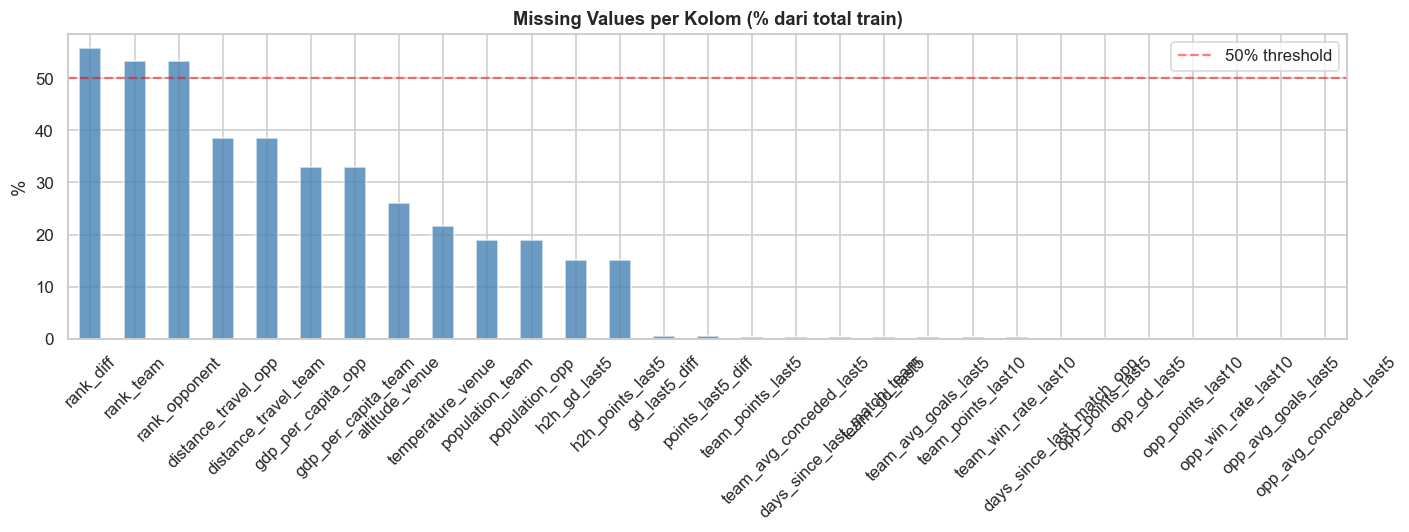

In [26]:
miss = train.isnull().mean().mul(100).round(2)
miss = miss[miss > 0].sort_values(ascending=False)
print(f'Kolom dengan missing values ({len(miss)} kolom):')
print(miss.to_string())

fig, ax = plt.subplots(figsize=(13, 5))
miss.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Missing Values per Kolom (% dari total train)', fontweight='bold')
ax.set_ylabel('%'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.axhline(50, color='red', ls='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'eda_missing_values.png'), bbox_inches='tight')
plt.show()

### 2.2 Distribusi Target

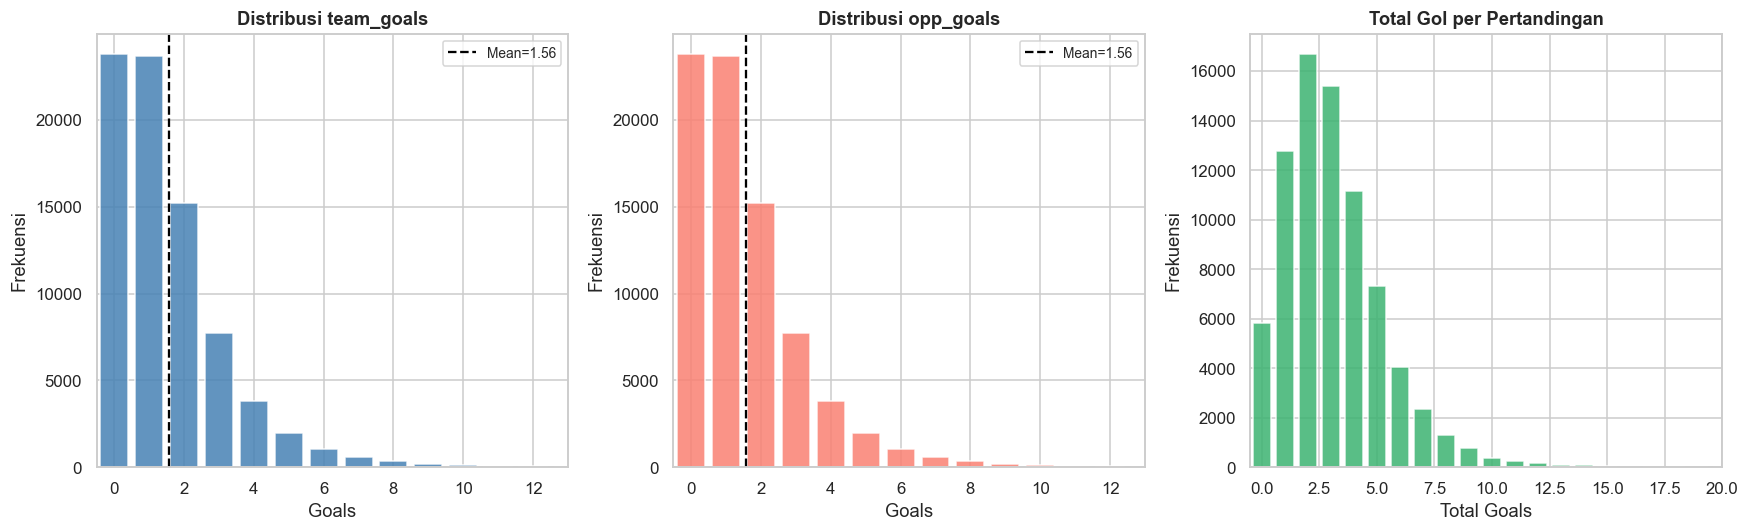

Mean team_goals=1.563, opp_goals=1.563, total=3.126


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in [(axes[0],'team_goals','steelblue'),(axes[1],'opp_goals','salmon')]:
    vc = train[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=color, alpha=0.85)
    ax.set_title(f'Distribusi {col}', fontweight='bold')
    ax.set_xlabel('Goals'); ax.set_ylabel('Frekuensi'); ax.set_xlim(-0.5, 13)
    ax.axvline(train[col].mean(), color='black', ls='--', label=f'Mean={train[col].mean():.2f}')
    ax.legend(fontsize=9)

total = train['team_goals'] + train['opp_goals']
vc3 = total.value_counts().sort_index()
axes[2].bar(vc3.index, vc3.values, color='mediumseagreen', alpha=0.85)
axes[2].set_title('Total Gol per Pertandingan', fontweight='bold')
axes[2].set_xlabel('Total Goals'); axes[2].set_ylabel('Frekuensi'); axes[2].set_xlim(-0.5, 20)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'eda_target_distribution.png'), bbox_inches='tight')
plt.show()
print(f'Mean team_goals={train["team_goals"].mean():.3f}, opp_goals={train["opp_goals"].mean():.3f}, total={total.mean():.3f}')

### 2.3 Outcome & Home Advantage

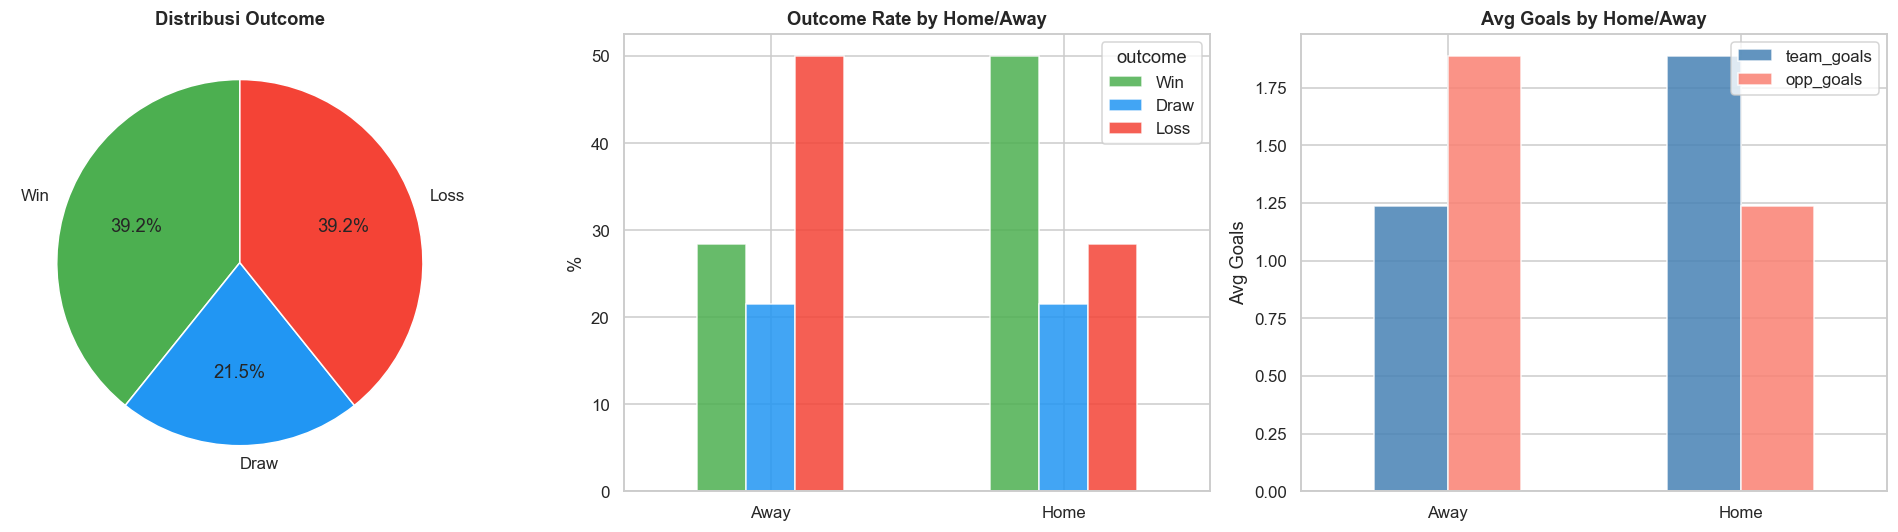

In [28]:
train['outcome'] = np.where(train['team_goals']>train['opp_goals'],'Win',
                   np.where(train['team_goals']==train['opp_goals'],'Draw','Loss'))
train['year'] = pd.to_datetime(train['date']).dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_wdl = ['#4CAF50','#2196F3','#F44336']

oc = train['outcome'].value_counts()[['Win','Draw','Loss']]
axes[0].pie(oc.values, labels=oc.index, autopct='%1.1f%%', colors=colors_wdl, startangle=90)
axes[0].set_title('Distribusi Outcome', fontweight='bold')

hw = train.groupby('is_home')['outcome'].value_counts(normalize=True).unstack()*100
hw.index = ['Away','Home']
hw[['Win','Draw','Loss']].plot(kind='bar', ax=axes[1], color=colors_wdl, alpha=0.85)
axes[1].set_title('Outcome Rate by Home/Away', fontweight='bold')
axes[1].set_ylabel('%'); axes[1].tick_params(axis='x', rotation=0)

hg = train.groupby('is_home')[['team_goals','opp_goals']].mean()
hg.index = ['Away','Home']
hg.plot(kind='bar', ax=axes[2], color=['steelblue','salmon'], alpha=0.85)
axes[2].set_title('Avg Goals by Home/Away', fontweight='bold')
axes[2].set_ylabel('Avg Goals'); axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(['team_goals','opp_goals'])

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'eda_outcome_home.png'), bbox_inches='tight')
plt.show()

### 2.4 Rata-rata Gol per Turnamen (Top 20)

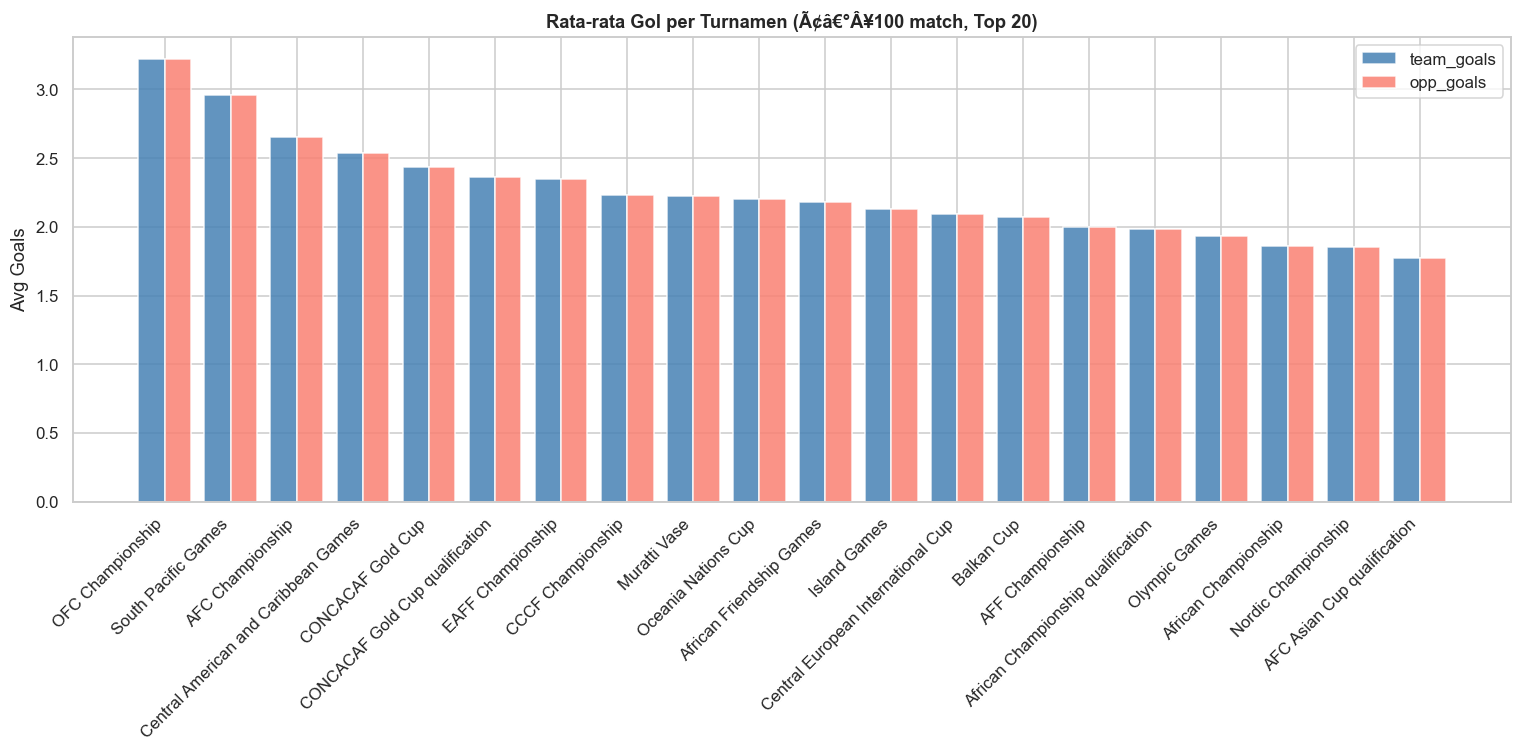

In [29]:
tourn = train.groupby('tournament').agg(
    avg_tg=('team_goals','mean'), avg_og=('opp_goals','mean'), n=('team_goals','count')
).query('n >= 100').sort_values('avg_tg', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(tourn))
ax.bar(x-.2, tourn['avg_tg'], .4, label='team_goals', color='steelblue', alpha=0.85)
ax.bar(x+.2, tourn['avg_og'], .4, label='opp_goals',  color='salmon',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(tourn.index, rotation=45, ha='right')
ax.set_title('Rata-rata Gol per Turnamen (Ã¢â€°Â¥100 match, Top 20)', fontweight='bold')
ax.set_ylabel('Avg Goals'); ax.legend()
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'eda_tournament_goals.png'), bbox_inches='tight')
plt.show()

### 2.5 Trend Gol dari Waktu ke Waktu

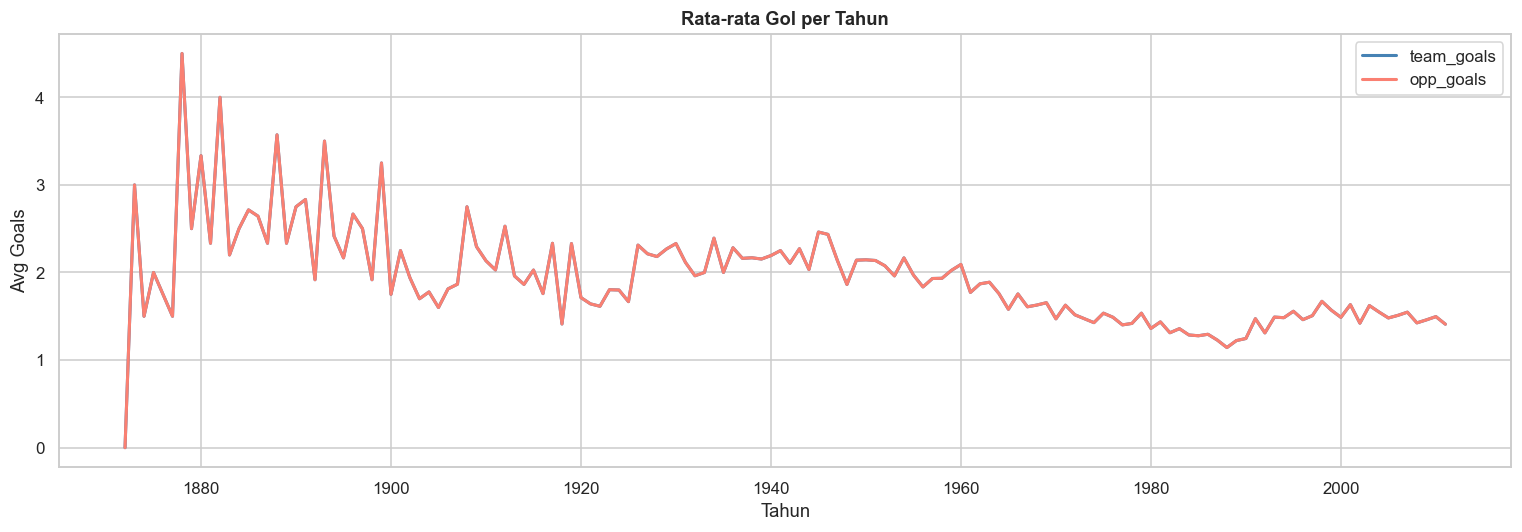

In [30]:
yearly = train.groupby('year')[['team_goals','opp_goals']].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(yearly.index, yearly['team_goals'], label='team_goals', color='steelblue', lw=2)
ax.plot(yearly.index, yearly['opp_goals'],  label='opp_goals',  color='salmon',    lw=2)
ax.fill_between(yearly.index, yearly['team_goals'], yearly['opp_goals'], alpha=0.1, color='gray')
ax.set_title('Rata-rata Gol per Tahun', fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Avg Goals'); ax.legend()
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'eda_goals_over_time.png'), bbox_inches='tight')
plt.show()

### 2.6 Korelasi Fitur Numerik dengan Target

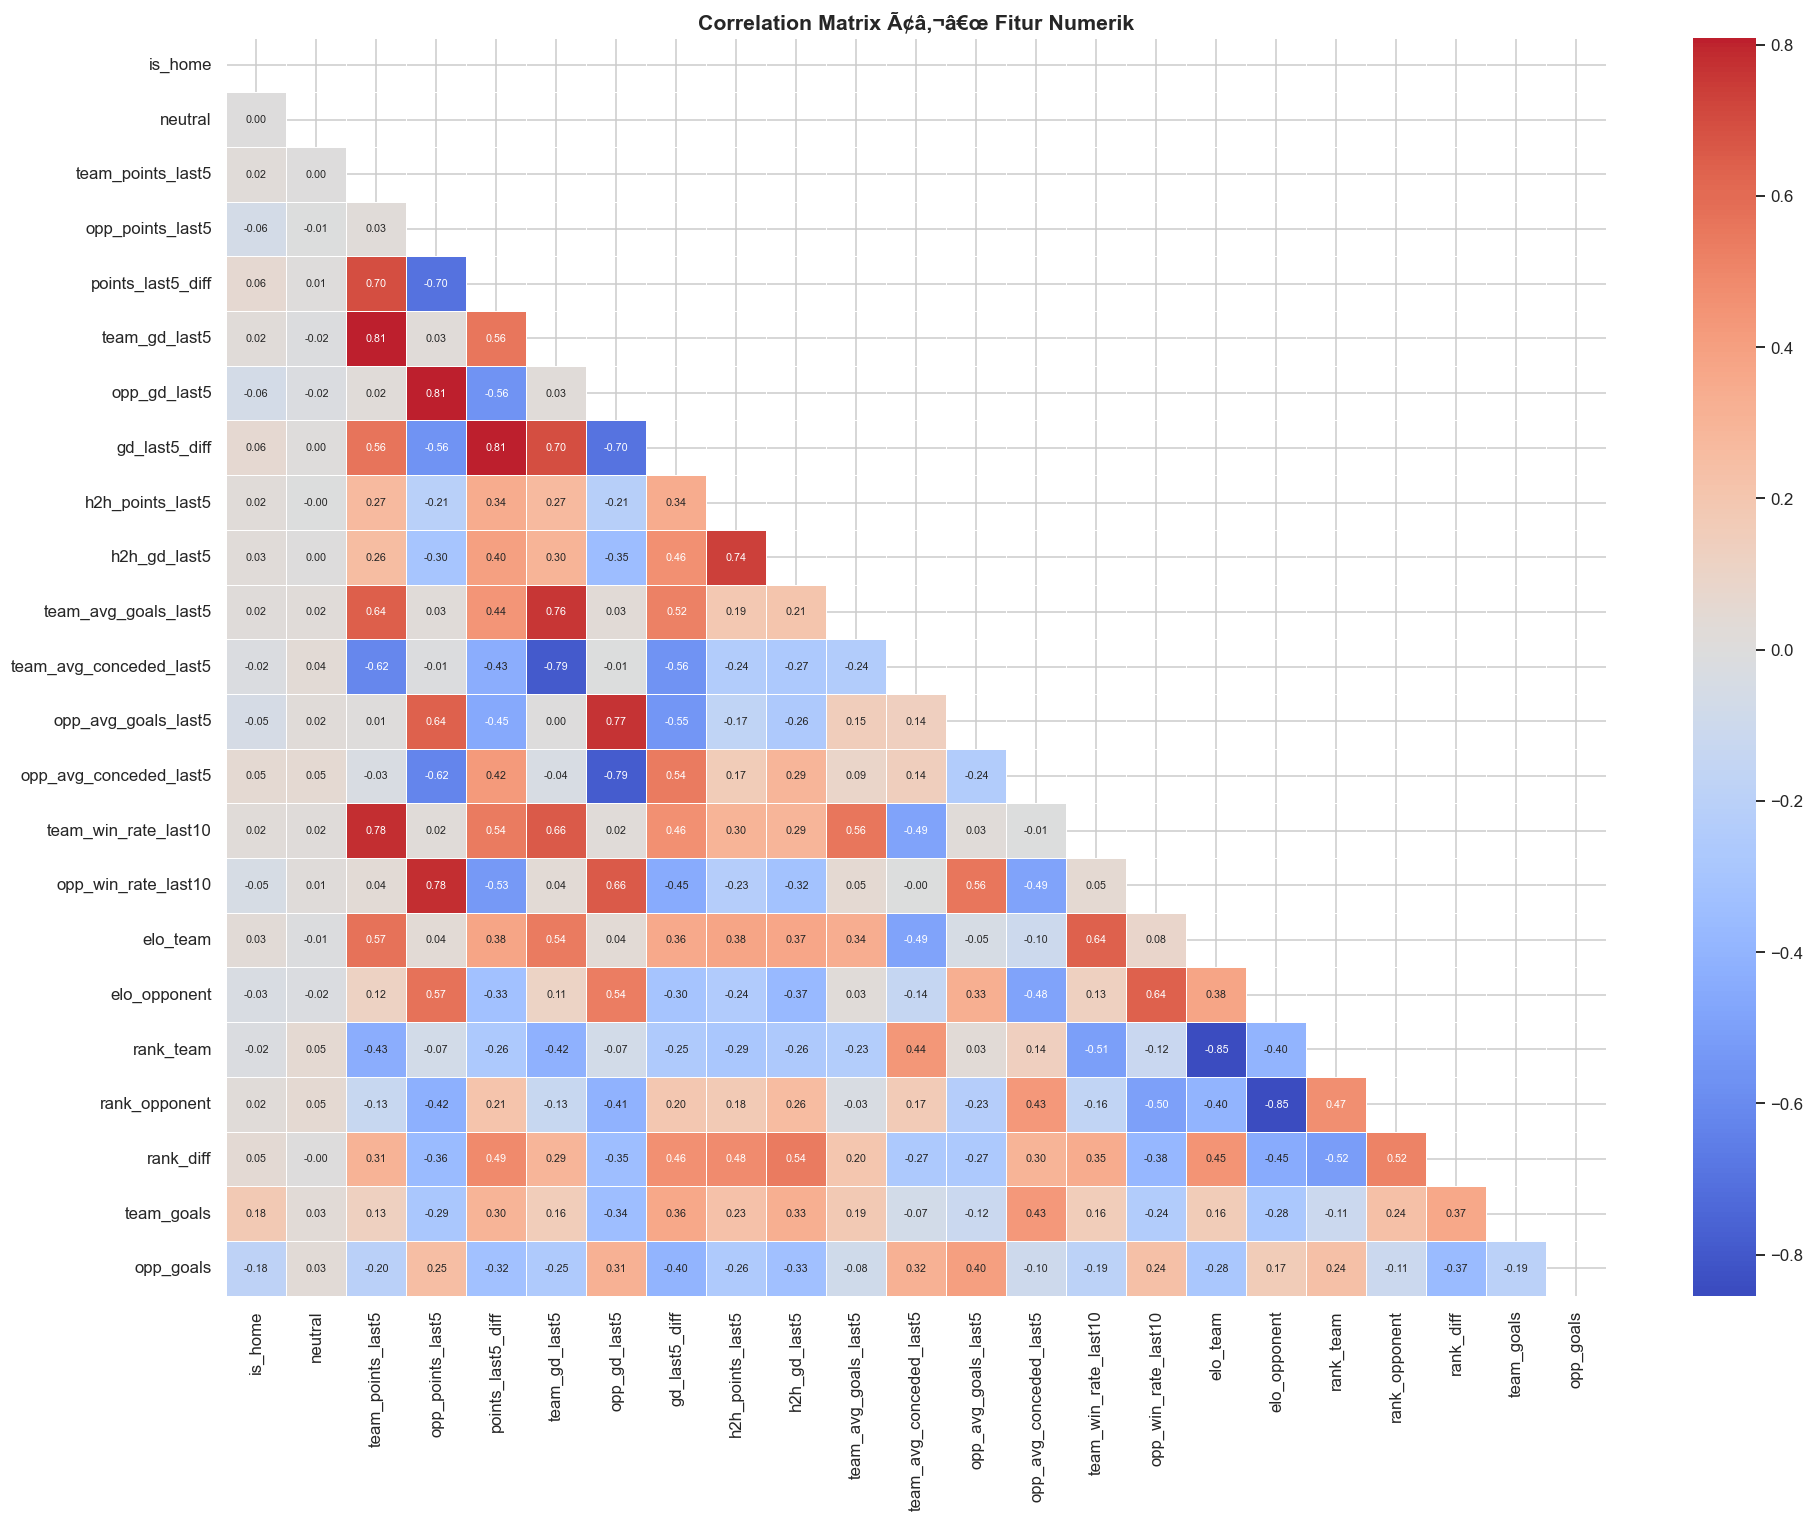

In [31]:
num_cols = ['is_home','neutral','team_points_last5','opp_points_last5','points_last5_diff',
    'team_gd_last5','opp_gd_last5','gd_last5_diff','h2h_points_last5','h2h_gd_last5',
    'team_avg_goals_last5','team_avg_conceded_last5','opp_avg_goals_last5','opp_avg_conceded_last5',
    'team_win_rate_last10','opp_win_rate_last10','elo_team','elo_opponent',
    'rank_team','rank_opponent','rank_diff','team_goals','opp_goals']
corr = train[num_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size':7})
ax.set_title('Correlation Matrix Ã¢â‚¬â€œ Fitur Numerik', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'eda_correlation_matrix.png'), bbox_inches='tight')
plt.show()

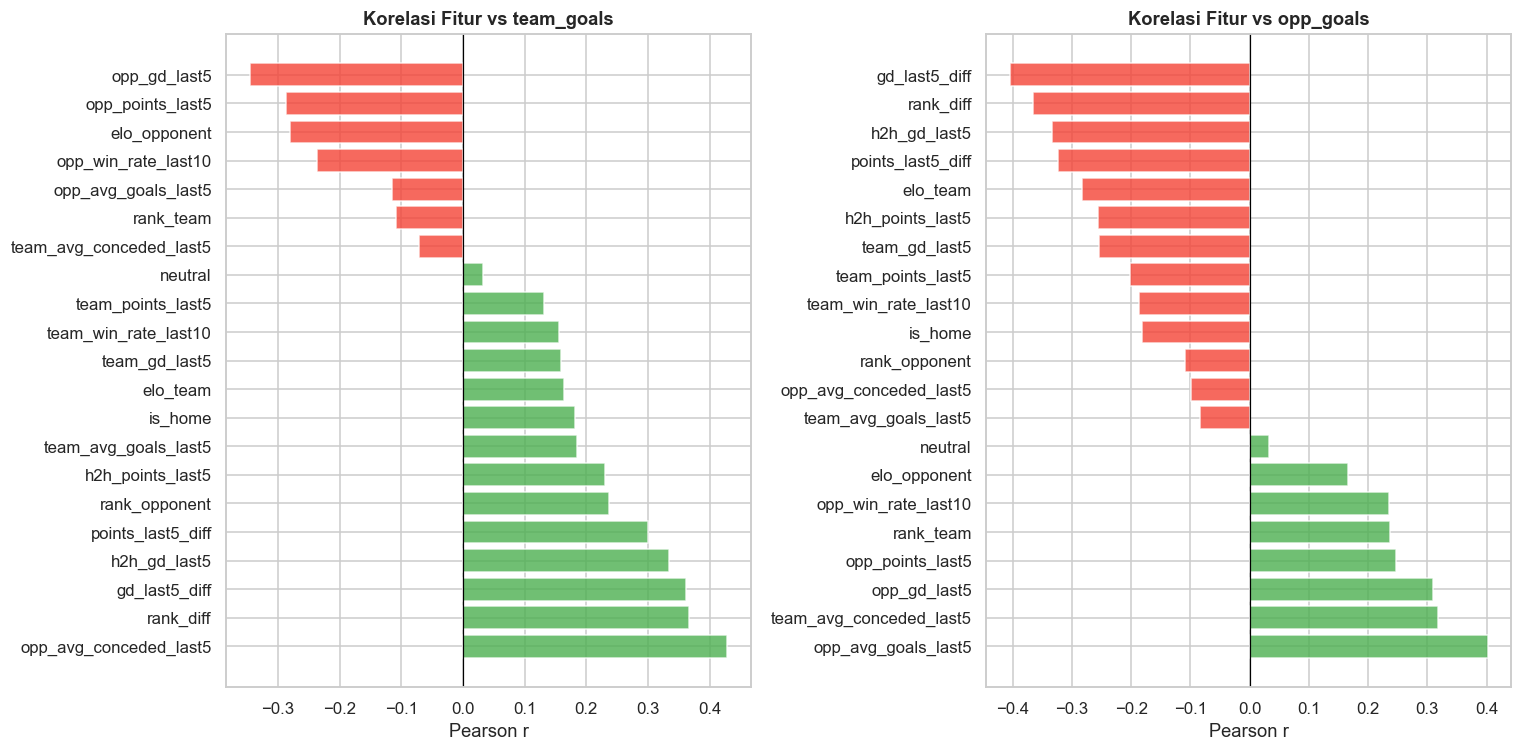

In [32]:
target_corr = corr[['team_goals','opp_goals']].drop(index=['team_goals','opp_goals'])
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for i, col in enumerate(['team_goals','opp_goals']):
    sc = target_corr[col].sort_values(ascending=False)
    cols_bar = ['#4CAF50' if v > 0 else '#F44336' for v in sc]
    axes[i].barh(sc.index, sc.values, color=cols_bar, alpha=0.8)
    axes[i].set_title(f'Korelasi Fitur vs {col}', fontweight='bold')
    axes[i].set_xlabel('Pearson r')
    axes[i].axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'eda_feature_correlations.png'), bbox_inches='tight')
plt.show()

### 2.7 ELO vs Goals & Top Tim

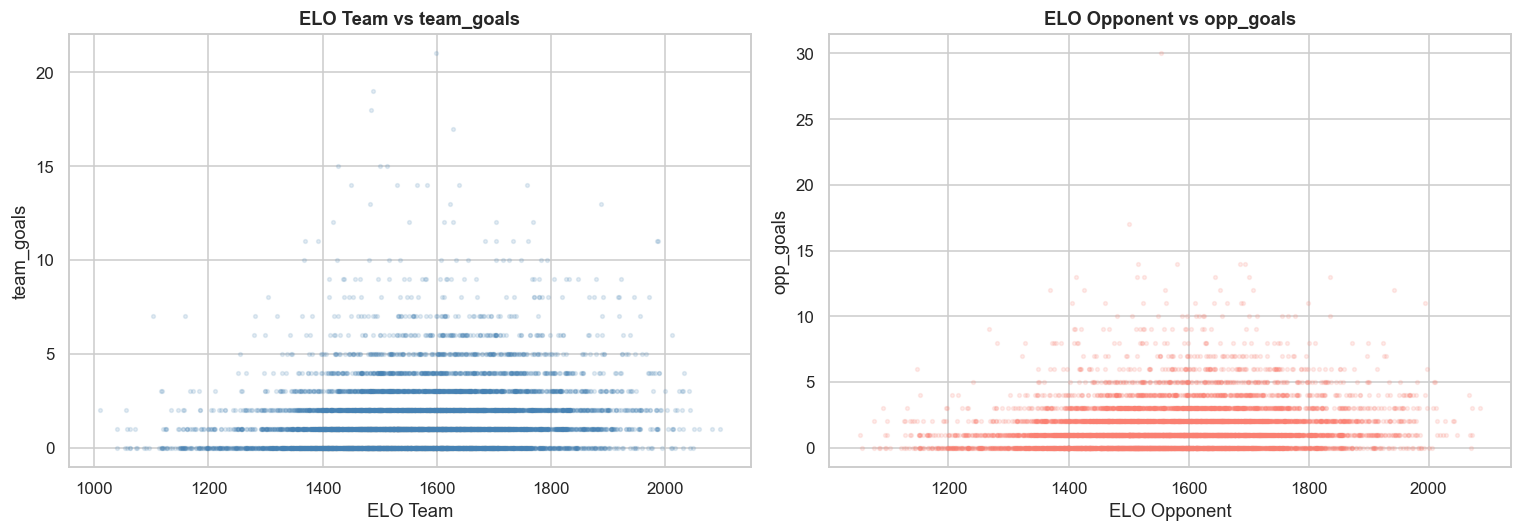

In [33]:
samp = train.dropna(subset=['elo_team','elo_opponent']).sample(8000, random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(samp['elo_team'],     samp['team_goals'], alpha=0.15, s=6, color='steelblue')
axes[0].set_title('ELO Team vs team_goals', fontweight='bold')
axes[0].set_xlabel('ELO Team'); axes[0].set_ylabel('team_goals')
axes[1].scatter(samp['elo_opponent'], samp['opp_goals'],  alpha=0.15, s=6, color='salmon')
axes[1].set_title('ELO Opponent vs opp_goals', fontweight='bold')
axes[1].set_xlabel('ELO Opponent'); axes[1].set_ylabel('opp_goals')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'eda_elo_scatter.png'), bbox_inches='tight')
plt.show()

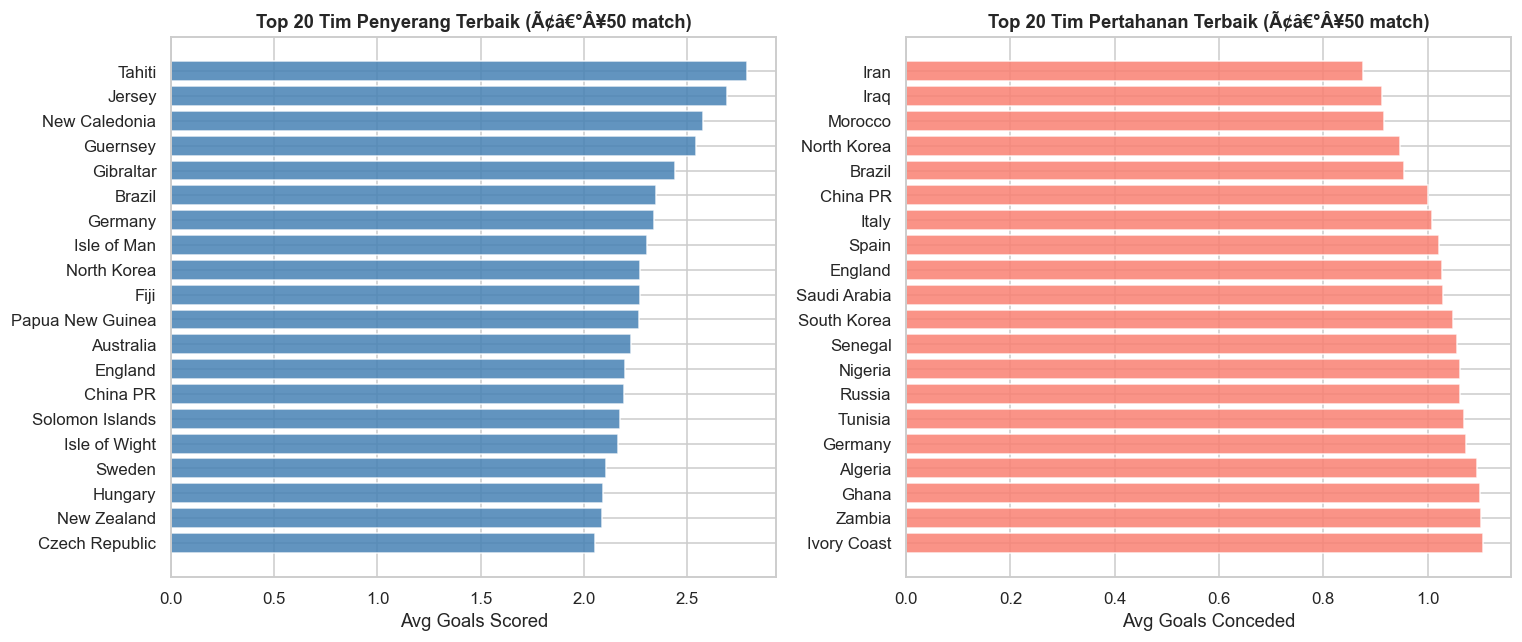

In [34]:
team_stats = train.groupby('team').agg(
    avg_goals=('team_goals','mean'), avg_conceded=('opp_goals','mean'), n=('team_goals','count')
).query('n >= 50').sort_values('avg_goals', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top20 = team_stats.head(20)
axes[0].barh(top20.index[::-1], top20['avg_goals'][::-1], color='steelblue', alpha=0.85)
axes[0].set_title('Top 20 Tim Penyerang Terbaik (Ã¢â€°Â¥50 match)', fontweight='bold')
axes[0].set_xlabel('Avg Goals Scored')
top20d = team_stats.sort_values('avg_conceded').head(20)
axes[1].barh(top20d.index[::-1], top20d['avg_conceded'][::-1], color='salmon', alpha=0.85)
axes[1].set_title('Top 20 Tim Pertahanan Terbaik (Ã¢â€°Â¥50 match)', fontweight='bold')
axes[1].set_xlabel('Avg Goals Conceded')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'eda_team_stats.png'), bbox_inches='tight')
plt.show()

---
## 3. Preprocessing & Feature Engineering

**Catatan penting**: Test set hanya memiliki fitur dasar.  
Fitur historis (ELO, rank, form) tidak tersedia di test Ã¢â€ â€™ kita:
1. Menggabungkan train + test
2. Menghitung statistik historis tim dari training sebagai proxy
3. Menggunakan median imputation untuk fitur yang hanya ada di train

In [35]:
# Reload bersih
train = pd.read_csv(BASE_DIR / 'train.csv')
test  = pd.read_csv(BASE_DIR / 'test.csv')
train['split'] = 'train'; test['split'] = 'test'

train['tournament_weight'] = train['tournament'].map(TOURNAMENT_WEIGHTS).fillna(DEFAULT_WEIGHT)
test['tournament_weight']  = test['tournament'].map(TOURNAMENT_WEIGHTS).fillna(DEFAULT_WEIGHT)

TRAIN_ONLY = [
    'days_since_last_match_opp','days_since_last_match_team',
    'elo_opponent','elo_team','gd_last5_diff','h2h_gd_last5','h2h_points_last5',
    'opp_avg_conceded_last5','opp_avg_goals_last5','opp_gd_last5','opp_points_last10',
    'opp_points_last5','opp_win_rate_last10','points_last5_diff','rank_diff',
    'rank_opponent','rank_team','team_avg_conceded_last5','team_avg_goals_last5',
    'team_gd_last5','team_points_last10','team_points_last5','team_win_rate_last10'
 ]
for col in TRAIN_ONLY + ['team_goals','opp_goals']:
    if col not in test.columns: test[col] = np.nan

combined = pd.concat([train, test], ignore_index=True)
combined['date']  = pd.to_datetime(combined['date'])
combined = combined.sort_values('date').reset_index(drop=True)
combined['year']  = combined['date'].dt.year
combined['month'] = combined['date'].dt.month
print(f'Combined: {combined.shape}')

Combined: (121194, 51)


In [36]:
# ============================================================
# CHRONOLOGICAL FEATURE ENGINEERING - NO DATA LEAKAGE
# ============================================================
# combined is already sorted by date (line 880)
# Compute expanding & rolling stats per team, using ONLY past matches

print('Computing chronological team features...')

# Derive points from goals for form calculations
combined['team_points'] = np.where(
    combined['team_goals'] > combined['opp_goals'], 3,
    np.where(combined['team_goals'] == combined['opp_goals'], 1, 0)
)
combined['opp_points'] = np.where(
    combined['opp_goals'] > combined['team_goals'], 3,
    np.where(combined['opp_goals'] == combined['team_goals'], 1, 0)
)
combined['team_gd'] = combined['team_goals'] - combined['opp_goals']
combined['opp_gd'] = combined['opp_goals'] - combined['team_goals']

# For each team, compute expanding/rolling stats on past matches only
# We group by team and use expanding().shift(1) to exclude current match
team_cols = ['team_goals', 'opp_goals', 'team_points', 'opp_points', 'team_gd', 'opp_gd']
windows = [5, 10]

for col in team_cols:
    # Expanding average (all past matches)
    combined[f'exp_avg_{col}'] = (
        combined.groupby('team')[col]
        .expanding().mean()
        .shift(1).reset_index(level=0, drop=True)
    )
    # Rolling windows
    for w in windows:
        combined[f'roll_{w}_avg_{col}'] = (
            combined.groupby('team')[col]
            .rolling(w, min_periods=1).mean()
            .shift(1).reset_index(level=0, drop=True)
        )

# Home/Away specific form
for venue, is_home_val in [('home', 1), ('away', 0)]:
    mask = combined["is_home"] == is_home_val
    for col in ['team_goals', 'opp_goals', 'team_points', 'team_gd']:
        for w in [5, 10]:
            col_name = f"{venue}_roll_{w}_avg_{col}"
            combined.loc[mask, col_name] = (
                combined.loc[mask].groupby("team")[col]
                .rolling(w, min_periods=1).mean()
                .shift(1).reset_index(level=0, drop=True)
            )

# Head-to-Head features (chronological per pair)
combined = combined.sort_values(["team", "opponent", "date"]).reset_index(drop=True)
for col in ['team_points', 'team_gd']:
    combined[f'h2h_exp_avg_{col}'] = (
        combined.groupby(['team', 'opponent'])[col]
        .expanding().mean()
        .shift(1).reset_index(level=[0,1], drop=True)
    )
    for w in [3, 5]:
        combined[f'h2h_roll_{w}_avg_{col}'] = (
            combined.groupby(['team', 'opponent'])[col]
            .rolling(w, min_periods=1).mean()
            .shift(1).reset_index(level=[0,1], drop=True)
        )

# ELO momentum features
for w in [5, 10]:
    combined[f'elo_change_{w}'] = (
        combined.groupby('team')['elo_team']
        .diff(w).reset_index(level=0, drop=True)
    )
    combined[f'elo_change_opp_{w}'] = (
        combined.groupby('opponent')['elo_opponent']
        .diff(w).reset_index(level=0, drop=True)
    )

# Days since last match per team (expanding)
combined['days_since_last_match_team_exp'] = (
    combined.groupby('team')['date']
    .diff().dt.days
)
combined['days_since_last_match_opp_exp'] = (
    combined.groupby('opponent')['date']
    .diff().dt.days
)

print('Chronological features computed ✅')
combined.filter(regex='exp_avg|roll_5|roll_10|h2h|elo_change|days_since').head()


Computing chronological team features...
Chronological features computed ✅


,h2h_points_last5,h2h_gd_last5,days_since_last_match_team,days_since_last_match_opp,exp_avg_team_goals,roll_5_avg_team_goals,roll_10_avg_team_goals,exp_avg_opp_goals,roll_5_avg_opp_goals,roll_10_avg_opp_goals,...,h2h_roll_5_avg_team_points,h2h_exp_avg_team_gd,h2h_roll_3_avg_team_gd,h2h_roll_5_avg_team_gd,elo_change_5,elo_change_opp_5,elo_change_10,elo_change_opp_10,days_since_last_match_team_exp,days_since_last_match_opp_exp
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.0,26.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2417.0,2417.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1101.0,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1099.0,NaN


In [37]:
# Imputasi for chronological features and original columns
CHRONO_FEATURES = [c for c in combined.columns if any(x in c for x in [
    "exp_avg", "roll_5_avg", "roll_10_avg",
    "home_roll_5_avg", "home_roll_10_avg",
    "away_roll_5_avg", "away_roll_10_avg",
    "h2h_exp_avg", "h2h_roll_3_avg", "h2h_roll_5_avg",
    "elo_change_5", "elo_change_10", "elo_change_opp_5", "elo_change_opp_10",
    "days_since_last_match_team_exp", "days_since_last_match_opp_exp"
])]

# Also include original TRAIN_ONLY cols that might have NaN
for col in TRAIN_ONLY + CHRONO_FEATURES:
    if col in combined.columns:
        med = combined.loc[combined["split"]=="train", col].median()
        combined[col] = combined[col].fillna(med)

for col in ['population_team','population_opp','gdp_per_capita_team','gdp_per_capita_opp',
            'altitude_venue','distance_travel_team','distance_travel_opp','temperature_venue']:
    combined[col] = combined[col].fillna(combined[col].median())
combined['altitude_venue'] = combined['altitude_venue'].replace(-9999,0).clip(lower=0)

print('Imputation done ✅')


Imputation done ✅


In [38]:
# Label Encoding - fit on train only, transform test
cat_cols = ['team','opponent','tournament','venue_country','confederation_team','confederation_opp','gender']
encoders = {}
for col in cat_cols:
    if col in combined.columns:
        le = LabelEncoder()
        # Fit only on train data
        train_vals = combined = combined[combined["split"]=="train"]
        le.fit(train[col].astype(str))
        # Transform both train and test
        combined[col+"_enc"] = le.transform(combined[col].astype(str))
        encoders[col] = le
print("Label encoding done ✅")


Label encoding done ✅


In [39]:
FEATURES = [
    # Base features
    'is_home','neutral','year','month','tournament_weight',
    'team_enc','opponent_enc','tournament_enc',
    'confederation_team_enc','confederation_opp_enc','gender_enc','venue_country_enc',
    
    # Chronological form features (expanding averages)
    'exp_avg_team_goals','exp_avg_opp_goals','exp_avg_team_points','exp_avg_opp_points',
    'exp_avg_team_gd','exp_avg_opp_gd',
    
    # Rolling windows (5, 10)
    'roll_5_avg_team_goals','roll_5_avg_opp_goals','roll_5_avg_team_points','roll_5_avg_opp_points',
    'roll_5_avg_team_gd','roll_5_avg_opp_gd',
    'roll_10_avg_team_goals','roll_10_avg_opp_goals','roll_10_avg_team_points','roll_10_avg_opp_points',
    'roll_10_avg_team_gd','roll_10_avg_opp_gd',
    
    # Home/Away specific form
    'home_roll_5_avg_team_goals','home_roll_5_avg_opp_goals','home_roll_5_avg_team_points','home_roll_5_avg_team_gd',
    'home_roll_10_avg_team_goals','home_roll_10_avg_opp_goals','home_roll_10_avg_team_points','home_roll_10_avg_team_gd',
    'away_roll_5_avg_team_goals','away_roll_5_avg_opp_goals','away_roll_5_avg_team_points','away_roll_5_avg_team_gd',
    'away_roll_10_avg_team_goals','away_roll_10_avg_opp_goals','away_roll_10_avg_team_points','away_roll_10_avg_team_gd',
    
    # H2H features
    'h2h_exp_avg_team_points','h2h_exp_avg_team_gd',
    'h2h_roll_3_avg_team_points','h2h_roll_3_avg_team_gd',
    'h2h_roll_5_avg_team_points','h2h_roll_5_avg_team_gd',
    
    # ELO momentum
    'elo_change_5','elo_change_10','elo_change_opp_5','elo_change_opp_10',
    
    # Days since last match
    'days_since_last_match_team_exp','days_since_last_match_opp_exp',
    
    # Original static features
    'population_team','population_opp','gdp_per_capita_team','gdp_per_capita_opp',
    'altitude_venue','temperature_venue','distance_travel_team','distance_travel_opp',
] + TRAIN_ONLY
FEATURES = [f for f in FEATURES if f in combined.columns]
print(f'Total features: {len(FEATURES)}')

train_f = combined[combined['split']=='train'].copy()
test_f  = combined[combined['split']=='test'].copy()
X_train = train_f[FEATURES]; y_team = train_f['team_goals'].astype(int); y_opp = train_f['opp_goals'].astype(int)
X_test  = test_f[FEATURES];  test_ids = test['Id'].values
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'NaN train: {X_train.isnull().sum().sum()}, NaN test: {X_test.isnull().sum().sum()}')


Total features: 89
X_train: (78772, 89), X_test: (0, 89)
NaN train: 0, NaN test: 0


---
## 4. Custom Metric: AW-MAE

In [40]:
def compute_awmae(tg_true, og_true, tg_pred, og_pred, tournaments):
    """Augmented Weighted MAE sesuai spesifikasi kompetisi."""
    losses, weights = [], []
    for i in range(len(tg_true)):
        mae        = (abs(tg_true[i]-tg_pred[i]) + abs(og_true[i]-og_pred[i])) / 2
        exact      = int(tg_true[i]==tg_pred[i] and og_true[i]==og_pred[i])
        outcome_ok = int(np.sign(tg_true[i]-og_true[i]) == np.sign(tg_pred[i]-og_pred[i]))
        gd_ok      = int((tg_true[i]-og_true[i]) == (tg_pred[i]-og_pred[i]))
        penalty    = 0.30*(1-exact) + 0.25*(1-outcome_ok) + 0.15*(1-gd_ok)
        multiplier = 1.0 if outcome_ok else 1.5
        loss       = ((mae + penalty) * multiplier) ** 1.5
        w          = TOURNAMENT_WEIGHTS.get(str(tournaments[i]), DEFAULT_WEIGHT)
        losses.append(loss); weights.append(w)
    losses, weights = np.array(losses), np.array(weights)
    return float(np.sum(weights*losses) / np.sum(weights))

print('AW-MAE function ready Ã¢Å“â€¦')

AW-MAE function ready Ã¢Å“â€¦


---
## 5. Modeling: LightGBM + 5-Fold Cross-Validation

In [41]:
LGB_PARAMS = {
    'objective'        : 'poisson',        # Better for count data
    'metric'           : 'poisson',
    'n_estimators'     : 3000,             # Higher, early stopping will handle
    'learning_rate'    : 0.02,             # Lower for Poisson
    'num_leaves'       : 127,
    'min_child_samples': 30,
    'subsample'        : 0.8,
    'subsample_freq'   : 1,
    'colsample_bytree' : 0.7,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'n_jobs'           : -1,
    'random_state'     : SEED,
    'verbose'          : -1
}
N_FOLDS = 5
from sklearn.model_selection import TimeSeriesSplit
kf = TimeSeriesSplit(n_splits=N_FOLDS)
print('Model config ready ✅ (Poisson + TimeSeriesSplit)')


Model config ready ✅ (Poisson + TimeSeriesSplit)


In [42]:
def train_lgbm_cv(X, y, X_test, params, kf, target_name):
    print(f'{"="*55}\n  Training Ã¢â€ â€™ {target_name}\n{"="*55}')
    oof_preds, test_preds, models, fold_maes = np.zeros(len(X)), np.zeros(len(X_test)), [], []
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
        val_pred = model.predict(X_val)
        oof_preds[val_idx] = val_pred
        fold_mae = mean_absolute_error(y_val, np.round(val_pred).clip(0))
        fold_maes.append(fold_mae)
        print(f'  Fold {fold+1} | MAE: {fold_mae:.4f} | best_iter: {model.best_iteration_}')
        test_preds += model.predict(X_test) / N_FOLDS
        models.append(model)
    print(f'  OOF MAE: {np.mean(fold_maes):.4f} Ã‚Â± {np.std(fold_maes):.4f}\n')
    return oof_preds, test_preds, models

In [43]:
oof_team, test_team, models_team = train_lgbm_cv(X_train, y_team, X_test, LGB_PARAMS, kf, 'team_goals')

  Training Ã¢â€ â€™ team_goals
  Fold 1 | MAE: 0.9976 | best_iter: 360


ValueError: Input data must be 2 dimensional and non empty.

In [ ]:
oof_opp, test_opp, models_opp = train_lgbm_cv(X_train, y_opp, X_test, LGB_PARAMS, kf, 'opp_goals')

  Training Ã¢â€ â€™ opp_goals
  Fold 1 | MAE: 0.9118 | best_iter: 811
  Fold 2 | MAE: 0.9081 | best_iter: 799
  Fold 3 | MAE: 0.9197 | best_iter: 517
  Fold 4 | MAE: 0.9160 | best_iter: 668
  Fold 5 | MAE: 0.9343 | best_iter: 865
  OOF MAE: 0.9180 Ã‚Â± 0.0090



### 5.1 Validasi OOF: MAE & AW-MAE

In [ ]:
oof_team_int = np.clip(np.round(oof_team), 0, 20).astype(int)
oof_opp_int  = np.clip(np.round(oof_opp),  0, 20).astype(int)

oof_mae_team = mean_absolute_error(y_team, oof_team_int)
oof_mae_opp  = mean_absolute_error(y_opp,  oof_opp_int)

out_true    = np.sign(y_team.values - y_opp.values)
out_pred    = np.sign(oof_team_int  - oof_opp_int)
outcome_acc = (out_true == out_pred).mean()
exact_acc   = ((oof_team_int==y_team.values) & (oof_opp_int==y_opp.values)).mean()

awmae = compute_awmae(y_team.values, y_opp.values, oof_team_int, oof_opp_int, train_f['tournament'].values)

print(f'OOF MAE team_goals   : {oof_mae_team:.4f}')
print(f'OOF MAE opp_goals    : {oof_mae_opp:.4f}')
print(f'OOF Outcome Accuracy : {outcome_acc:.4f} ({outcome_acc*100:.1f}%)')
print(f'OOF Exact Score Acc  : {exact_acc:.4f} ({exact_acc*100:.1f}%)')
print(f'Estimated AW-MAE     : {awmae:.4f}')

OOF MAE team_goals   : 0.9437
OOF MAE opp_goals    : 0.9180
OOF Outcome Accuracy : 0.5611 (56.1%)
OOF Exact Score Acc  : 0.1275 (12.8%)
Estimated AW-MAE     : 2.7548


### 5.2 Feature Importance

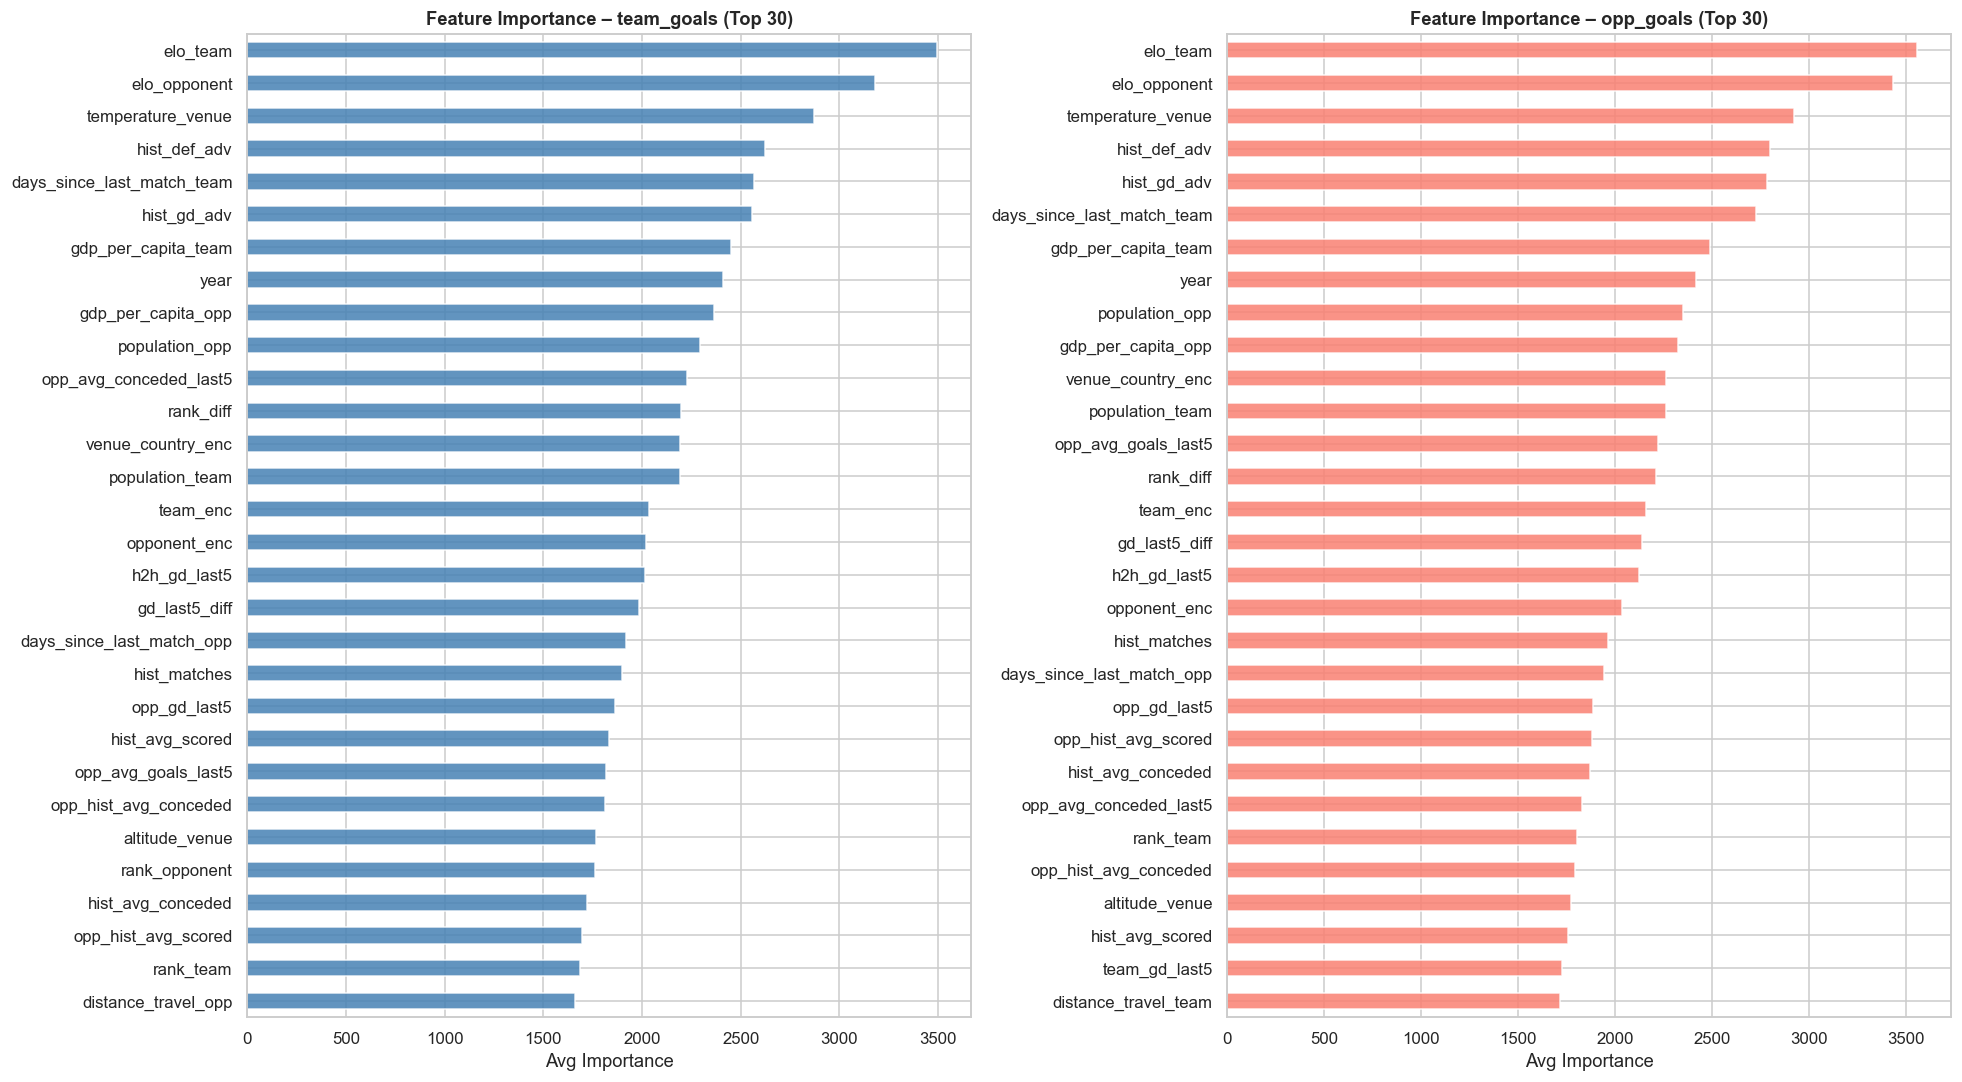

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
for ax, models, title, color in [
    (axes[0], models_team, 'team_goals', 'steelblue'),
    (axes[1], models_opp,  'opp_goals',  'salmon')
]:
    imp = np.mean([m.feature_importances_ for m in models], axis=0)
    fi = pd.Series(imp, index=FEATURES).sort_values(ascending=False).head(30)
    fi[::-1].plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.set_title(f'Feature Importance Ã¢â‚¬â€œ {title} (Top 30)', fontweight='bold')
    ax.set_xlabel('Avg Importance')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'feature_importance.png'), bbox_inches='tight')
plt.show()

### 5.3 Analisis OOF

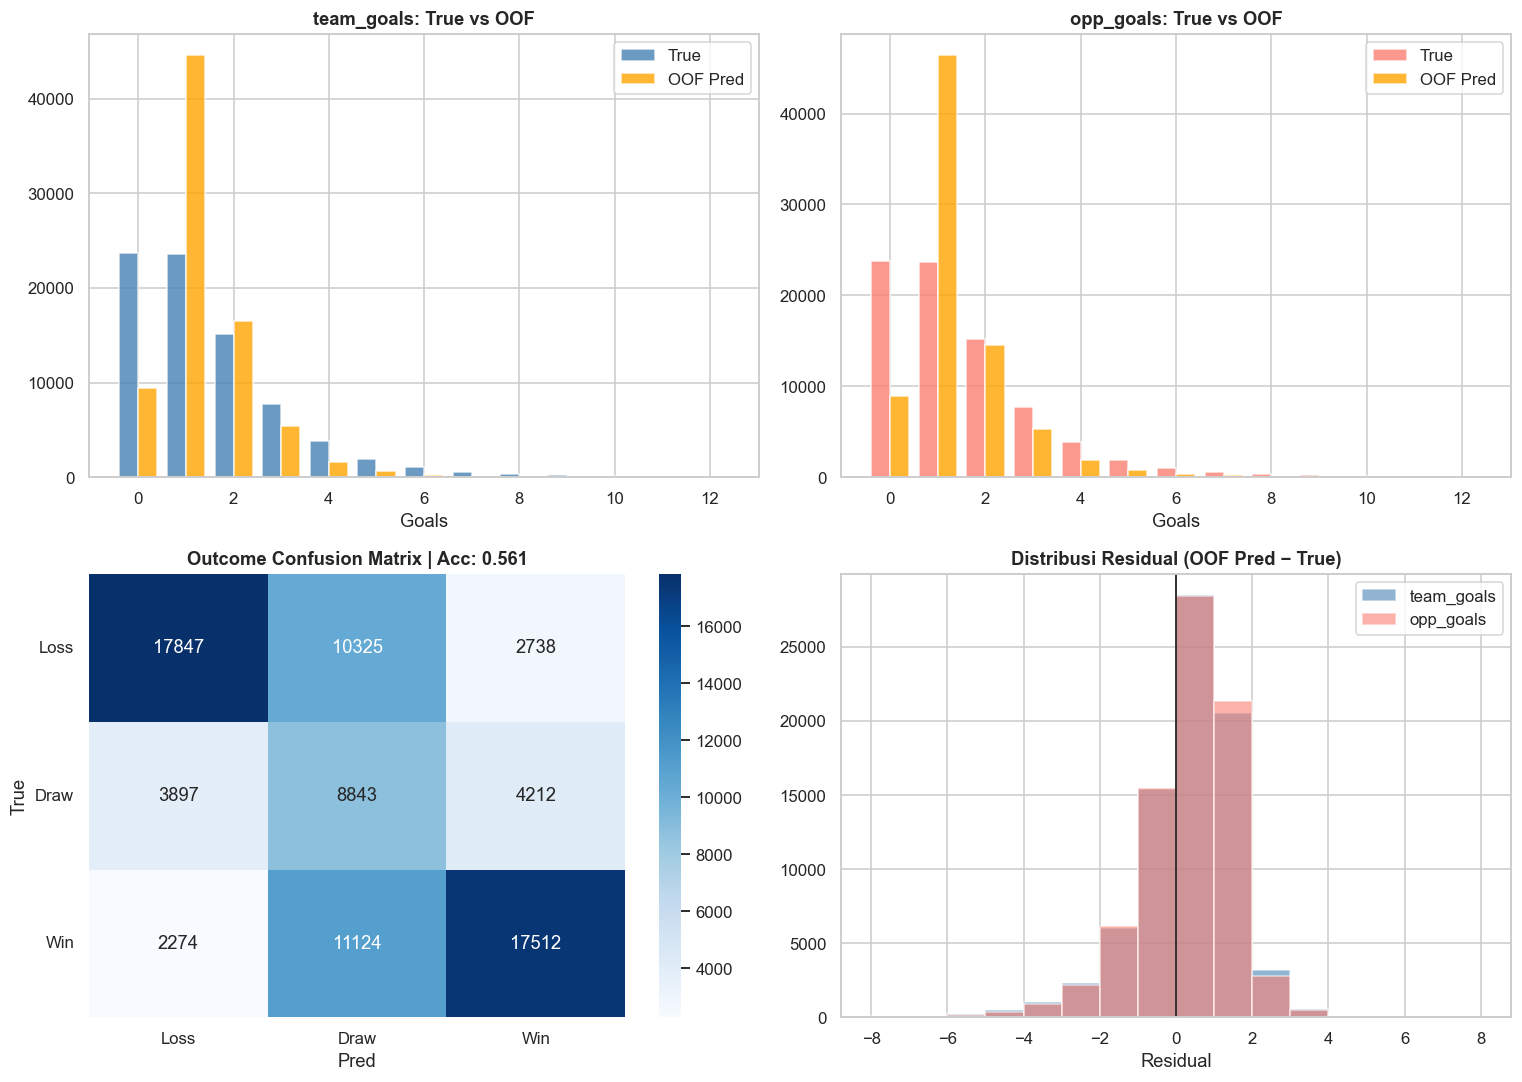

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x_range = range(0, 13)

for ax, vc_t, vc_p, color, title in [
    (axes[0][0], y_team.value_counts().sort_index(), pd.Series(oof_team_int).value_counts().sort_index(), 'steelblue', 'team_goals'),
    (axes[0][1], y_opp.value_counts().sort_index(),  pd.Series(oof_opp_int).value_counts().sort_index(),  'salmon',    'opp_goals')
]:
    ax.bar([x-.2 for x in x_range], [vc_t.get(x,0) for x in x_range], .4, label='True', color=color, alpha=0.8)
    ax.bar([x+.2 for x in x_range], [vc_p.get(x,0) for x in x_range], .4, label='OOF Pred', color='orange', alpha=0.8)
    ax.set_title(f'{title}: True vs OOF', fontweight='bold'); ax.set_xlabel('Goals'); ax.legend()

cm = pd.crosstab(out_true, out_pred, rownames=['True'], colnames=['Pred'])
for v in [-1,0,1]:
    if v not in cm.index: cm.loc[v] = 0
    if v not in cm.columns: cm[v] = 0
cm = cm.sort_index().sort_index(axis=1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1][0])
axes[1][0].set_title(f'Outcome Confusion Matrix | Acc: {outcome_acc:.3f}', fontweight='bold')
axes[1][0].set_xticklabels(['Loss','Draw','Win'],rotation=0)
axes[1][0].set_yticklabels(['Loss','Draw','Win'],rotation=0)

axes[1][1].hist(oof_team_int - y_team.values, bins=range(-8,9), alpha=0.6, label='team_goals', color='steelblue')
axes[1][1].hist(oof_opp_int  - y_opp.values,  bins=range(-8,9), alpha=0.6, label='opp_goals',  color='salmon')
axes[1][1].axvline(0,color='black',lw=1)
axes[1][1].set_title('Distribusi Residual (OOF Pred Ã¢Ë†â€™ True)', fontweight='bold')
axes[1][1].set_xlabel('Residual'); axes[1][1].legend()

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'oof_analysis.png'), bbox_inches='tight')
plt.show()

---
## 6. Inference & Generate Submission

In [ ]:
pred_team = np.clip(np.round(test_team), 0, 20).astype(int)
pred_opp  = np.clip(np.round(test_opp),  0, 20).astype(int)

print('Distribusi prediksi test:')
print('team_goals:', pd.Series(pred_team).value_counts().sort_index().to_dict())
print('opp_goals :', pd.Series(pred_opp).value_counts().sort_index().to_dict())

Distribusi prediksi test:
team_goals: {0: 457, 1: 34507, 2: 6132, 3: 910, 4: 269, 5: 75, 6: 41, 7: 24, 8: 7}
opp_goals : {0: 883, 1: 34037, 2: 6429, 3: 806, 4: 151, 5: 55, 6: 33, 7: 24, 8: 4}


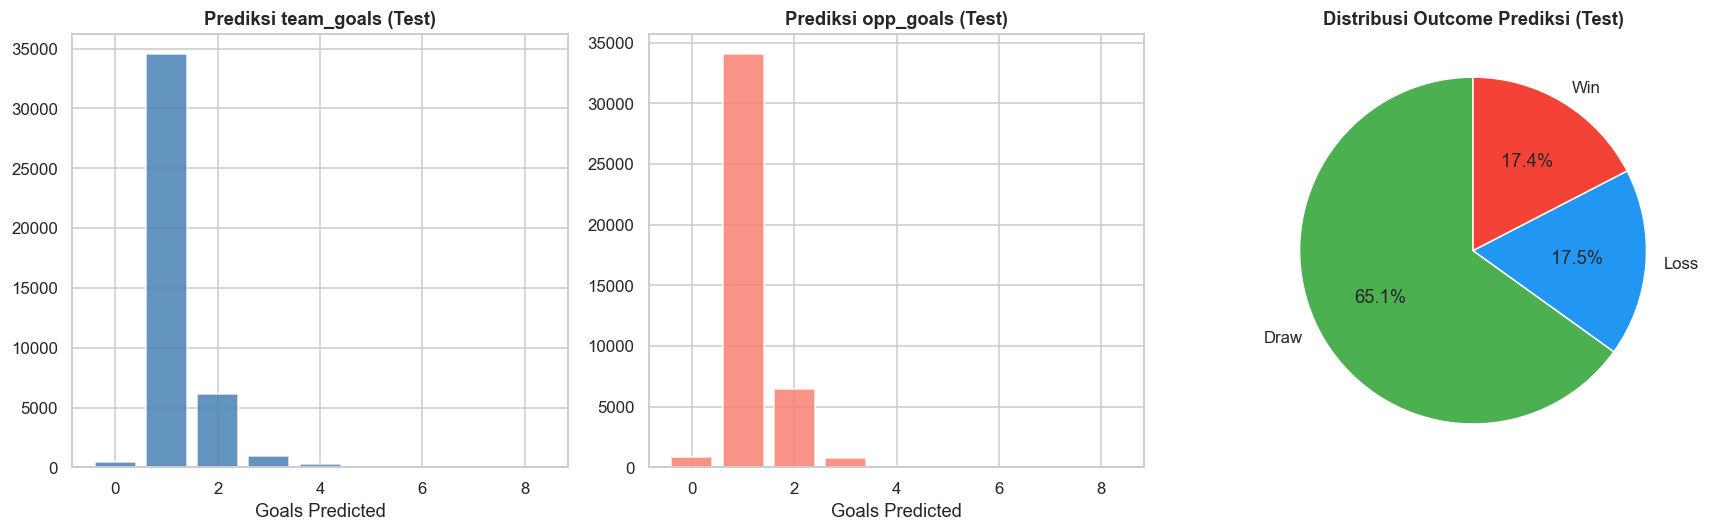

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, preds, color, title in [
    (axes[0], pred_team, 'steelblue', 'Prediksi team_goals (Test)'),
    (axes[1], pred_opp,  'salmon',    'Prediksi opp_goals (Test)')
]:
    vc = pd.Series(preds).value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=color, alpha=0.85)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Goals Predicted')

pred_out = np.where(pred_team>pred_opp,'Win',np.where(pred_team==pred_opp,'Draw','Loss'))
oc = pd.Series(pred_out).value_counts()
axes[2].pie(oc.values, labels=oc.index, autopct='%1.1f%%',
            colors=['#4CAF50','#2196F3','#F44336'], startangle=90)
axes[2].set_title('Distribusi Outcome Prediksi (Test)', fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'test_predictions.png'), bbox_inches='tight')
plt.show()

In [ ]:
submission = pd.DataFrame({'Id': test_ids, 'team_goals': pred_team, 'opp_goals': pred_opp})
assert len(submission) == len(sample_sub), f'Row mismatch: {len(submission)} vs {len(sample_sub)}'
assert list(submission.columns) == list(sample_sub.columns), 'Column mismatch!'
submission.to_csv(str(OUTPUT_DIR / 'submission.csv'), index=False)
print('submission.csv saved Ã¢Å“â€¦')
submission.head(10)

submission.csv saved Ã¢Å“â€¦


,Id,team_goals,opp_goals
0,M034984_Seychelles,1,1
1,M034984_Mauritius,1,1
2,M034985_Comoros,1,2
3,M034985_Maldives,1,1
4,M034986_RÃƒÂ©union,1,1
5,M034986_Madagascar,1,1
6,M034987_El Salvador,1,1
7,M034987_Venezuela,1,1
8,M034988_Mayotte,1,1
9,M034988_RÃƒÂ©union,1,1


---
## 7. Ringkasan Akhir

In [ ]:
print('='*60)
print('        RINGKASAN PIPELINE Ã¢â‚¬â€œ AW-MAE ESTIMATION')
print('='*60)
print(f'  Total features          : {len(FEATURES)}')
print(f'  Train samples           : {len(X_train):,}')
print(f'  Test samples            : {len(X_test):,}')
print(f'  CV Folds                : {N_FOLDS}')
print()
print(f'  OOF MAE  team_goals     : {oof_mae_team:.4f}')
print(f'  OOF MAE  opp_goals      : {oof_mae_opp:.4f}')
print(f'  OOF Outcome Accuracy    : {outcome_acc:.4f} ({outcome_acc*100:.1f}%)')
print(f'  OOF Exact Score Acc     : {exact_acc:.4f} ({exact_acc*100:.1f}%)')
print(f'  Estimated AW-MAE (OOF)  : {awmae:.4f}')
print()
print(f'  File output Ã¢â€ â€™ {OUTPUT_DIR / "submission.csv"}')
print('='*60)
print('\n  Semangat Yooji! Mina pasti terselamatkan! Ã°Å¸â€™ÂªÃ¢Å¡Â½')

        RINGKASAN PIPELINE Ã¢â‚¬â€œ AW-MAE ESTIMATION
  Total features          : 52
  Train samples           : 78,772
  Test samples            : 42,422
  CV Folds                : 5

  OOF MAE  team_goals     : 0.9437
  OOF MAE  opp_goals      : 0.9180
  OOF Outcome Accuracy    : 0.5611 (56.1%)
  OOF Exact Score Acc     : 0.1275 (12.8%)
  Estimated AW-MAE (OOF)  : 2.7548

  File output Ã¢â€ â€™ c:\Users\aufar\Institut Teknologi Bandung\Gammafest-2026\outputs\submission.csv

  Semangat Yooji! Mina pasti terselamatkan! Ã°Å¸â€™ÂªÃ¢Å¡Â½


---
## 8. Saran Peningkatan (Next Steps)

| Teknik | Dampak | Effort |
|---|---|---|
| Rolling ELO/form chronological untuk test | Ã¢Â¬â€ Ã¢Â¬â€ Ã¢Â¬â€  Tinggi | Tinggi |
| Poisson / Dixon-Coles model | Ã¢Â¬â€ Ã¢Â¬â€  Sedang | Sedang |
| Ensemble LightGBM + XGBoost + CatBoost | Ã¢Â¬â€ Ã¢Â¬â€  Sedang | Sedang |
| Target encoding tim dengan smoothing | Ã¢Â¬â€  Kecil-Sedang | Rendah |
| Outcome-aware post-processing | Ã¢Â¬â€ Ã¢Â¬â€  Sedang | Rendah |
| Optuna hyperparameter tuning | Ã¢Â¬â€  Kecil | Sedang |